# Sandbox de Exploração - Modelo M1 (Tendências)
Objetivo: Testar a previsão de tendências (Séries Temporais), avaliando várias técnicas de normalização e modelos, culminando na implementação final (SARIMA).

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

import warnings
warnings.filterwarnings('ignore')

_PG_HOST = os.environ.get("PG_HOST", "localhost")
_PG_PORT = os.environ.get("PG_PORT", "5432")
URL_SANDBOX = f"postgresql+psycopg2://ae_user:ae_pass_2026@{_PG_HOST}:{_PG_PORT}/auto_escala"

engine = create_engine(URL_SANDBOX)
print("Engine conectada com sucesso!")

Engine conectada com sucesso!


In [2]:
# Carregar dados
query = """
    SELECT marca_key, tipo_key, combustivel_key, localizacao_key, ano, mes, valor_interesse AS valor
    FROM auto_escala_dw.vw_mart_prev_tendencias
    WHERE valor_interesse IS NOT NULL
    ORDER BY 1, 2, 3, 4, 5, 6
"""

df_m1 = pd.read_sql(query, engine)
grupo_keys = df_m1.groupby(['marca_key', 'tipo_key', 'combustivel_key', 'localizacao_key']).size().idxmax()
serie_exemplo = df_m1[(df_m1['marca_key']==grupo_keys[0]) & (df_m1['tipo_key']==grupo_keys[1]) & (df_m1['combustivel_key']==grupo_keys[2]) & (df_m1['localizacao_key']==grupo_keys[3])].copy()
serie_exemplo = serie_exemplo.sort_values(['ano','mes']).reset_index(drop=True)

print(f"Observações da série exemplo: {len(serie_exemplo)}")
display(serie_exemplo.head())

Observações da série exemplo: 24


,marca_key,tipo_key,combustivel_key,localizacao_key,ano,mes,valor
0,-1,-1,1,1,2022,1,43.0
1,-1,-1,1,1,2022,2,54.0
2,-1,-1,1,1,2022,3,42.0
3,-1,-1,1,1,2022,4,49.0
4,-1,-1,1,1,2022,5,51.0


## 1. Testes de Normalização
Vamos testar diferentes escalas na nossa série temporal.

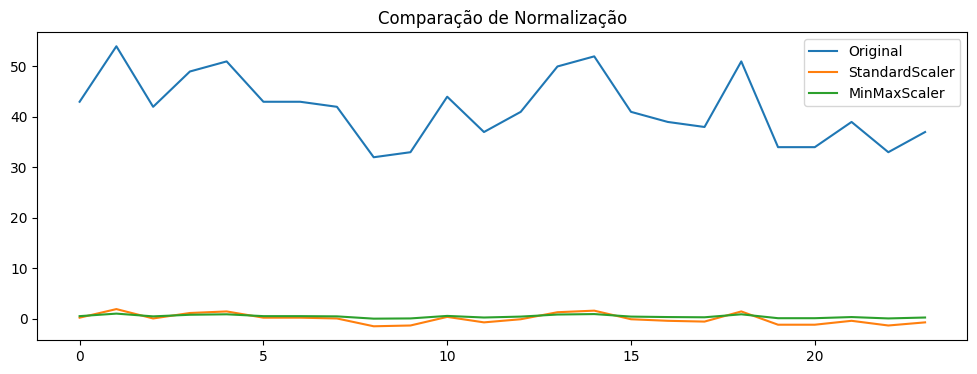

In [3]:
# Extrair target
y = serie_exemplo['valor'].values.reshape(-1, 1)

# StandardScaler
scaler_std = StandardScaler()
y_std = scaler_std.fit_transform(y)

# MinMaxScaler
scaler_minmax = MinMaxScaler()
y_minmax = scaler_minmax.fit_transform(y)

# Plot comparativo
plt.figure(figsize=(12, 4))
plt.plot(y, label='Original')
plt.plot(y_std, label='StandardScaler')
plt.plot(y_minmax, label='MinMaxScaler')
plt.legend()
plt.title("Comparação de Normalização")
plt.show()

## 2. Testes com Outros Modelos
Vamos usar regressão linear (Ridge) e Random Forest usando features de lag (janela deslizante) com e sem normalização.

In [4]:
# Criar lags
serie_exemplo['lag1'] = serie_exemplo['valor'].shift(1)
serie_exemplo['lag2'] = serie_exemplo['valor'].shift(2)
df_ml = serie_exemplo.dropna().copy()

X = df_ml[['lag1', 'lag2']]
y_target = df_ml['valor']

# Split temporal (últimos 3 meses para teste)
X_train, X_test = X[:-3], X[-3:]
y_train, y_test = y_target[:-3], y_target[-3:]

# Ridge (Sem normalizar)
ridge = Ridge()
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print(f"MAE Ridge: {mean_absolute_error(y_test, pred_ridge):.4f}")
print(f"MAE Random Forest: {mean_absolute_error(y_test, pred_rf):.4f}")

MAE Ridge: 4.4481
MAE Random Forest: 5.6333


## 3. Modelo Final Escolhido: SARIMA
O SARIMA lidou melhor com a nossa série temporal porque trata a sazonalidade diretamente sem precisarmos de construir manualmente matrizes de *lags* muito grandes.
Vamos usar `pmdarima` para descobrir a melhor configuração auto-regressiva.

In [5]:
# Usamos log1p como método de normalização do nosso modelo em produção (semelhante a Box-Cox)
treino = np.log1p(y_target[:-3])
teste_real = y_target[-3:]

modelo_sarima = pm.auto_arima(
    treino,
    seasonal=True,
    m=12 if len(treino) >= 24 else 1, # Ajusta se tiver dados suficientes
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    information_criterion="aic"
)

print(modelo_sarima.summary())

previsoes_log = modelo_sarima.predict(n_periods=3)
previsoes_finais = np.expm1(previsoes_log)

print(f"MAE SARIMA (Transformado): {mean_absolute_error(teste_real, previsoes_finais):.4f}")

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   19
Model:                        SARIMAX   Log Likelihood                   9.511
Date:                Sat, 23 May 2026   AIC                            -15.022
Time:                        19:38:08   BIC                            -13.133
Sample:                             0   HQIC                           -14.703
                                 - 19                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      3.7481      0.034    111.035      0.000       3.682       3.814
sigma2         0.0215      0.010      2.114      0.035       0.002       0.041
Ljung-Box (L1) (Q):                   1.37   Jarque-